In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

In [2]:
df = pd.read_csv("cleaned_weather.csv")
df.head()

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


In [3]:
print(df.shape)
print(df.columns)
print(df.isna().sum())

(52696, 21)
Index(['date', 'p', 'T', 'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh',
       'H2OC', 'rho', 'wv', 'max. wv', 'wd', 'rain', 'raining', 'SWDR', 'PAR',
       'max. PAR', 'Tlog'],
      dtype='object')
date        0
p           0
T           0
Tpot        0
Tdew        0
rh          0
VPmax       0
VPact       0
VPdef       0
sh          0
H2OC        0
rho         0
wv          0
max. wv     0
wd          0
rain        0
raining     0
SWDR        0
PAR         0
max. PAR    0
Tlog        0
dtype: int64


In [4]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour
df['minute'] = df['date'].dt.minute
df['day_of_week'] = df['date'].dt.dayofweek

df.head()

,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,SWDR,PAR,max. PAR,Tlog,year,month,day,hour,minute,day_of_week
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,0.0,0.0,0.0,11.45,2020,1,1,0,10,2
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,0.0,0.0,0.0,11.51,2020,1,1,0,20,2
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,0.0,0.0,0.0,11.60,2020,1,1,0,30,2
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,0.0,0.0,0.0,11.70,2020,1,1,0,40,2
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,0.0,0.0,0.0,11.81,2020,1,1,0,50,2


In [5]:
df = df.replace(-9999, np.nan)

print(df.isna().sum())

date            0
p               0
T               0
Tpot            0
Tdew            0
rh              0
VPmax           0
VPact           0
VPdef           0
sh              0
H2OC            0
rho             0
wv              1
max. wv         0
wd              0
rain            0
raining         0
SWDR            0
PAR             0
max. PAR       30
Tlog            0
year            0
month           0
day             0
hour            0
minute          0
day_of_week     0
dtype: int64


In [6]:
# Fill missing values
df['wv'] = df['wv'].fillna(df['wv'].mean())
df['max. PAR'] = df['max. PAR'].interpolate(method='linear')

print(df.isna().sum())

date           0
p              0
T              0
Tpot           0
Tdew           0
rh             0
VPmax          0
VPact          0
VPdef          0
sh             0
H2OC           0
rho            0
wv             0
max. wv        0
wd             0
rain           0
raining        0
SWDR           0
PAR            0
max. PAR       0
Tlog           0
year           0
month          0
day            0
hour           0
minute         0
day_of_week    0
dtype: int64


In [7]:
def wavelet_packet_denoise(signal, wavelet='db4', maxlevel=4, threshold_mode='soft'):
    wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, mode='symmetric', maxlevel=maxlevel)
    new_wp = pywt.WaveletPacket(data=None, wavelet=wavelet, mode='symmetric')

    nodes = wp.get_level(maxlevel, order='freq')
    all_coeffs = np.concatenate([n.data for n in nodes])

    sigma = np.median(np.abs(all_coeffs - np.median(all_coeffs))) / 0.6745
    T = sigma * np.sqrt(2 * np.log(len(signal)))

    for node in nodes:
        new_wp[node.path] = pywt.threshold(node.data, T, mode=threshold_mode)

    denoised = new_wp.reconstruct(update=True)
    return denoised[:len(signal)]

In [8]:
denoised_df = df.copy()

for col in ['T', 'Tpot', 'p', 'wv']:
    # Step 1: Wavelet denoising
    denoised_signal = wavelet_packet_denoise(df[col].values)
    
    # Step 2: Convert to series
    denoised_series = pd.Series(denoised_signal, index=df.index)
    
    # Step 3: Light smoothing
    denoised_df[col] = denoised_series.rolling(window=3, min_periods=1).mean()

print(" Denoising completed")

 Denoising completed


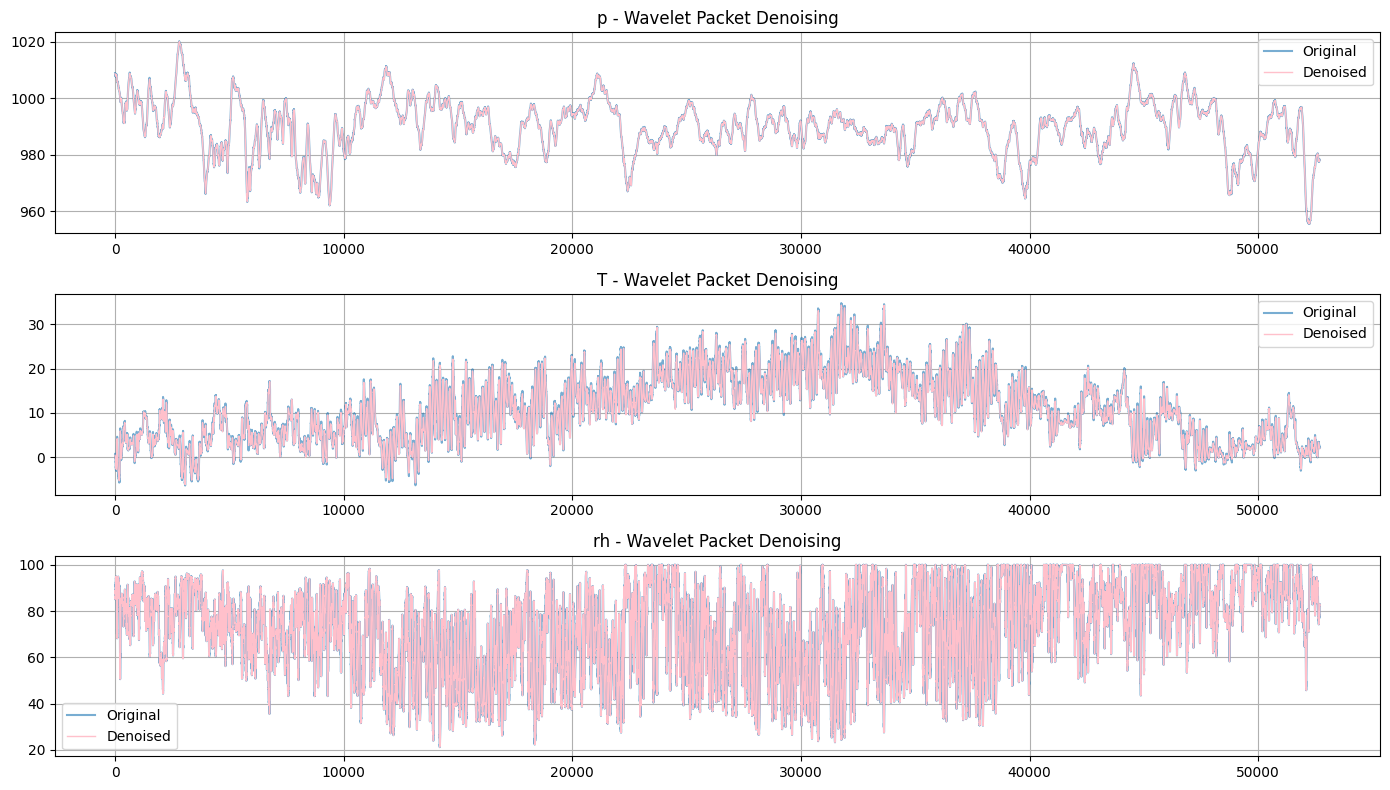

In [9]:
cols = ['p', 'T', 'rh']

plt.figure(figsize=(14, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.plot(df[col], label='Original', alpha=0.6)
    plt.plot(denoised_df[col], label='Denoised', color='pink', linewidth=1)
    plt.title(f'{col} - Wavelet Packet Denoising')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

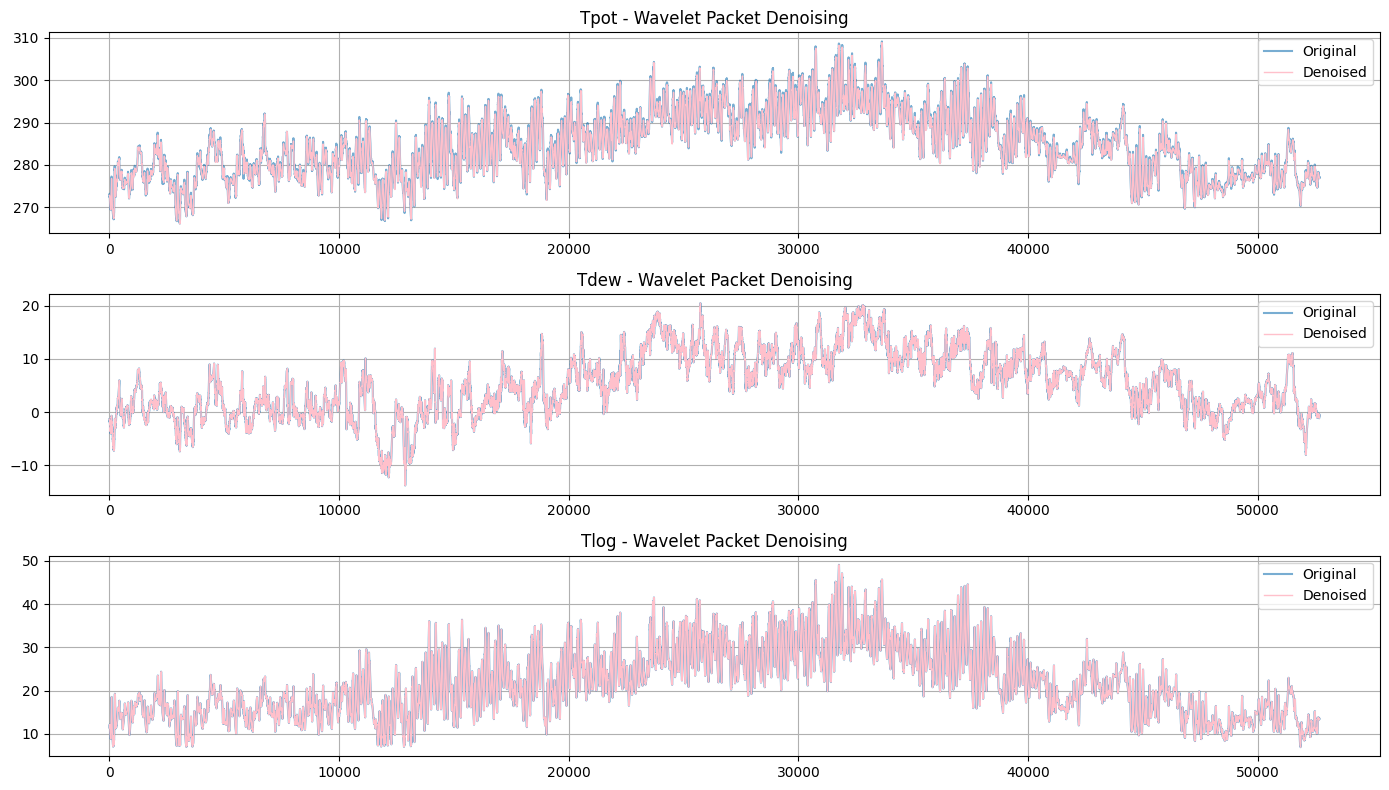

In [10]:
cols = ['Tpot', 'Tdew', 'Tlog']

plt.figure(figsize=(14, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.plot(df[col], label='Original', alpha=0.6)
    plt.plot(denoised_df[col], label='Denoised',color='pink', linewidth=1)
    plt.title(f'{col} - Wavelet Packet Denoising')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

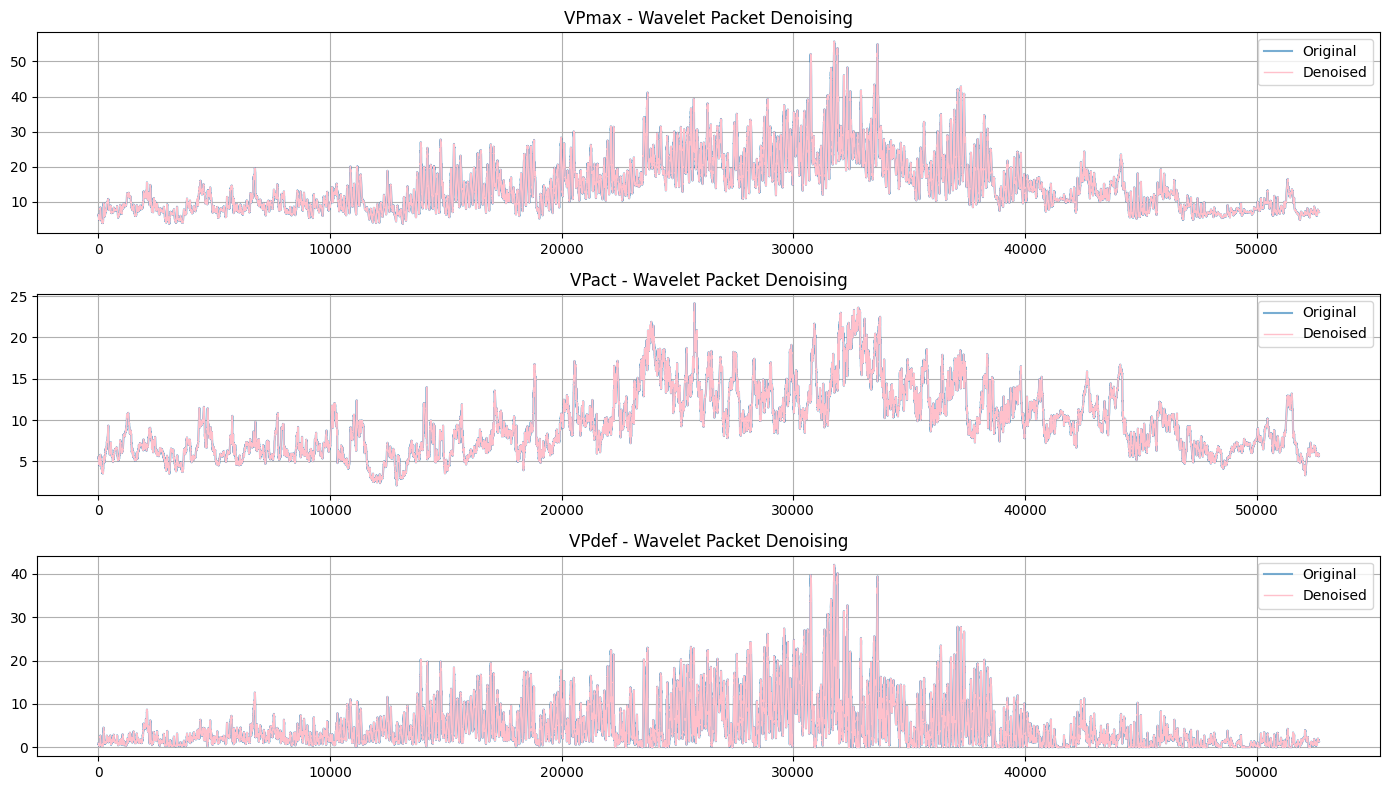

In [11]:
cols = ['VPmax', 'VPact', 'VPdef']

plt.figure(figsize=(14, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.plot(df[col], label='Original', alpha=0.6)
    plt.plot(denoised_df[col], label='Denoised',color='pink', linewidth=1)
    plt.title(f'{col} - Wavelet Packet Denoising')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

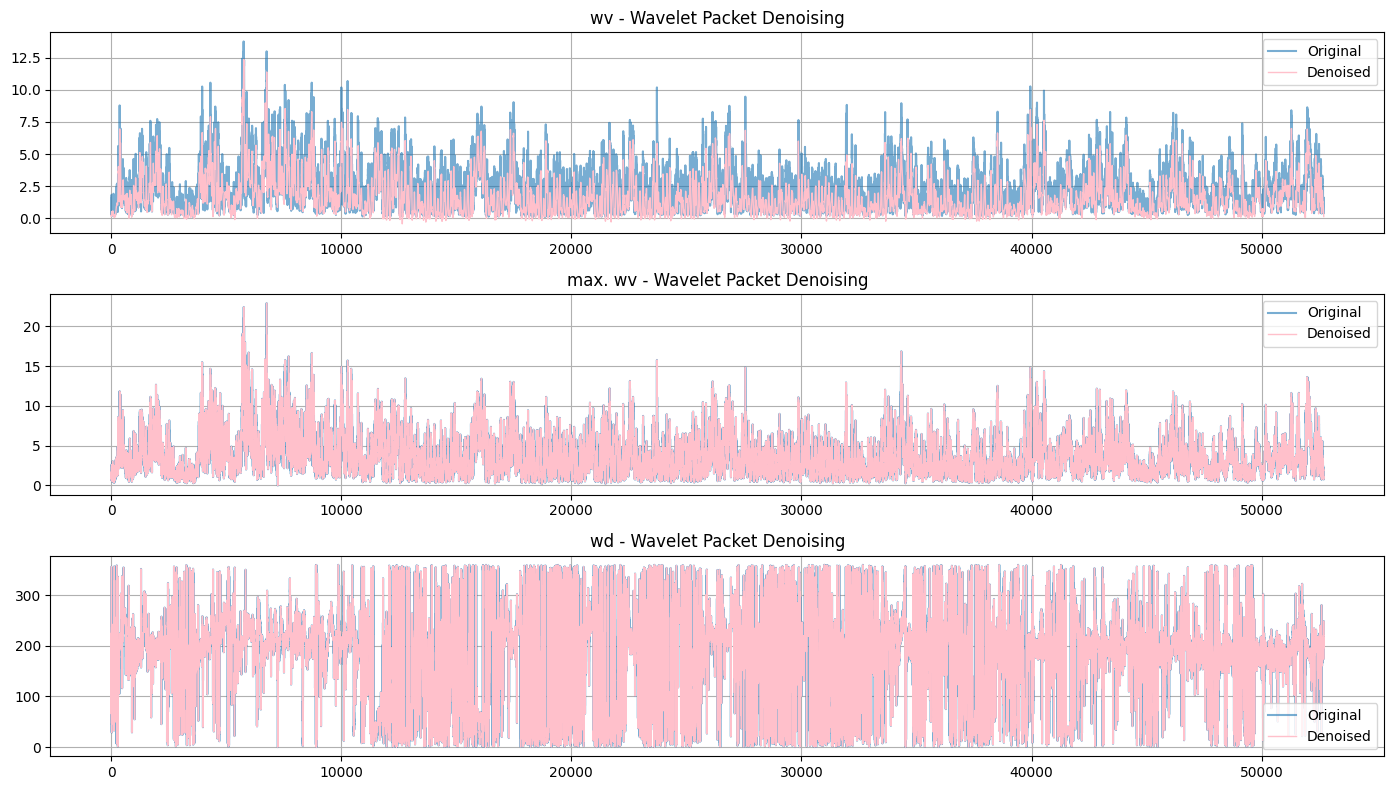

In [12]:
cols = ['wv', 'max. wv', 'wd']

plt.figure(figsize=(14, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.plot(df[col], label='Original', alpha=0.6)
    plt.plot(denoised_df[col], label='Denoised',color='pink', linewidth=1)
    plt.title(f'{col} - Wavelet Packet Denoising')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

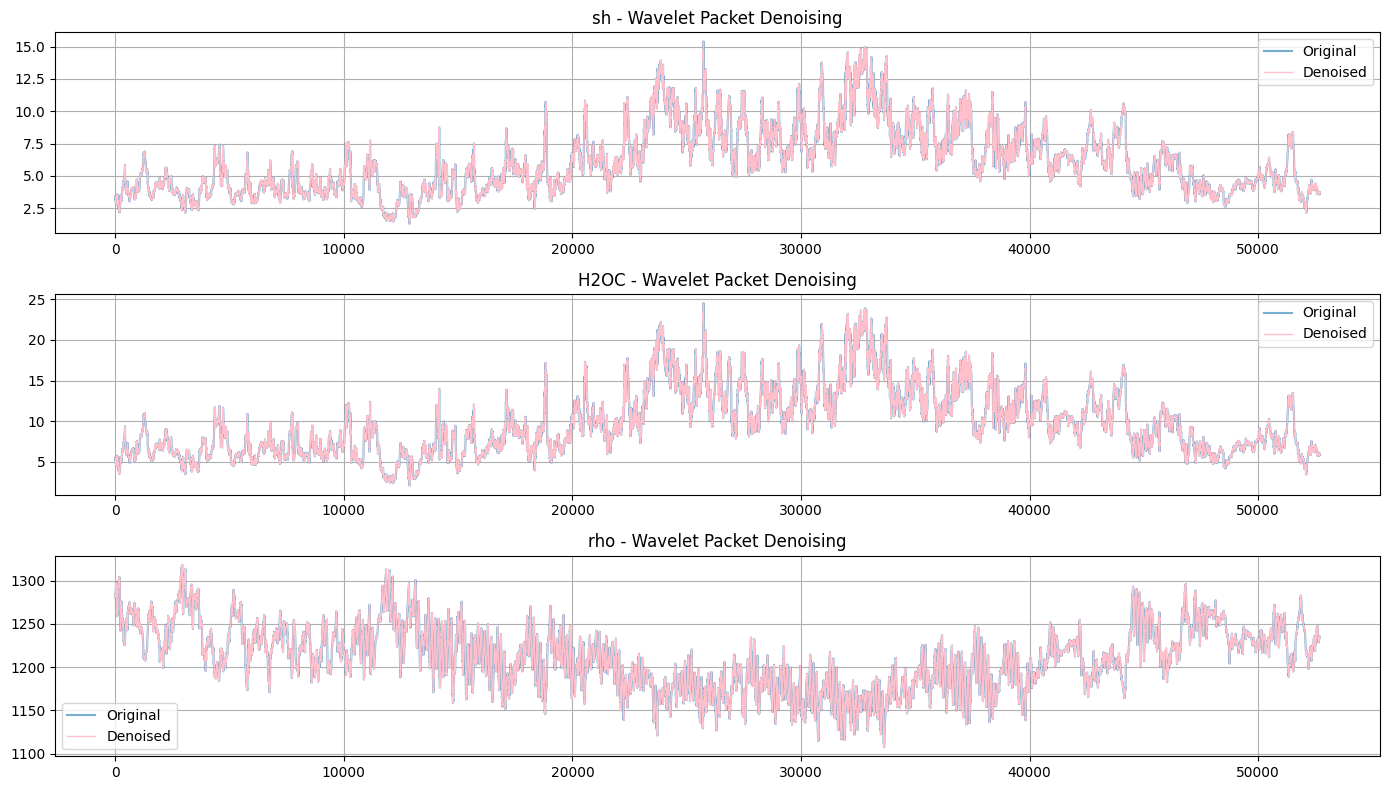

In [13]:
cols = ['sh', 'H2OC', 'rho']

plt.figure(figsize=(14, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.plot(df[col], label='Original', alpha=0.6)
    plt.plot(denoised_df[col], label='Denoised',color='pink', linewidth=1)
    plt.title(f'{col} - Wavelet Packet Denoising')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

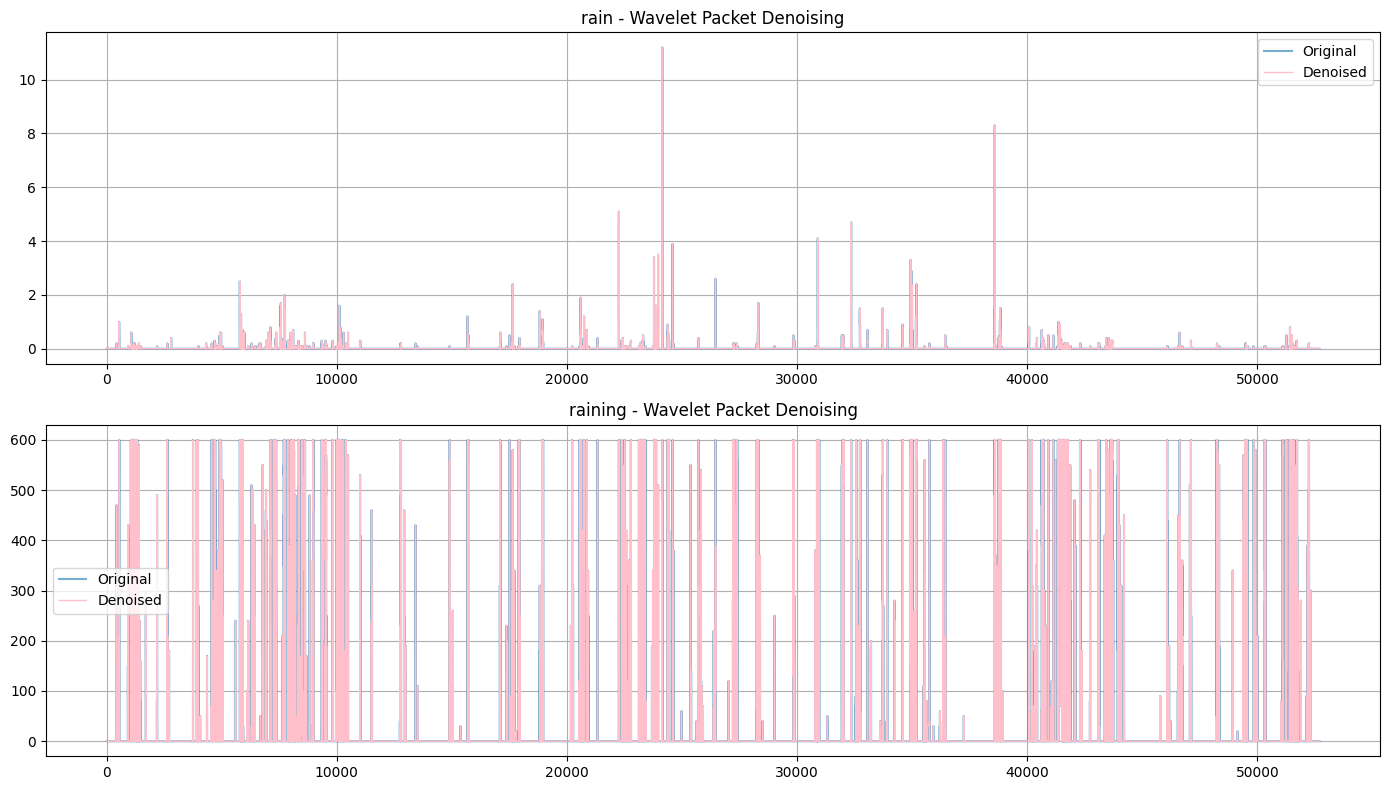

In [14]:
cols = ['rain','raining']

plt.figure(figsize=(14, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.plot(df[col], label='Original', alpha=0.6)
    plt.plot(denoised_df[col], label='Denoised',color='pink', linewidth=1)
    plt.title(f'{col} - Wavelet Packet Denoising')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

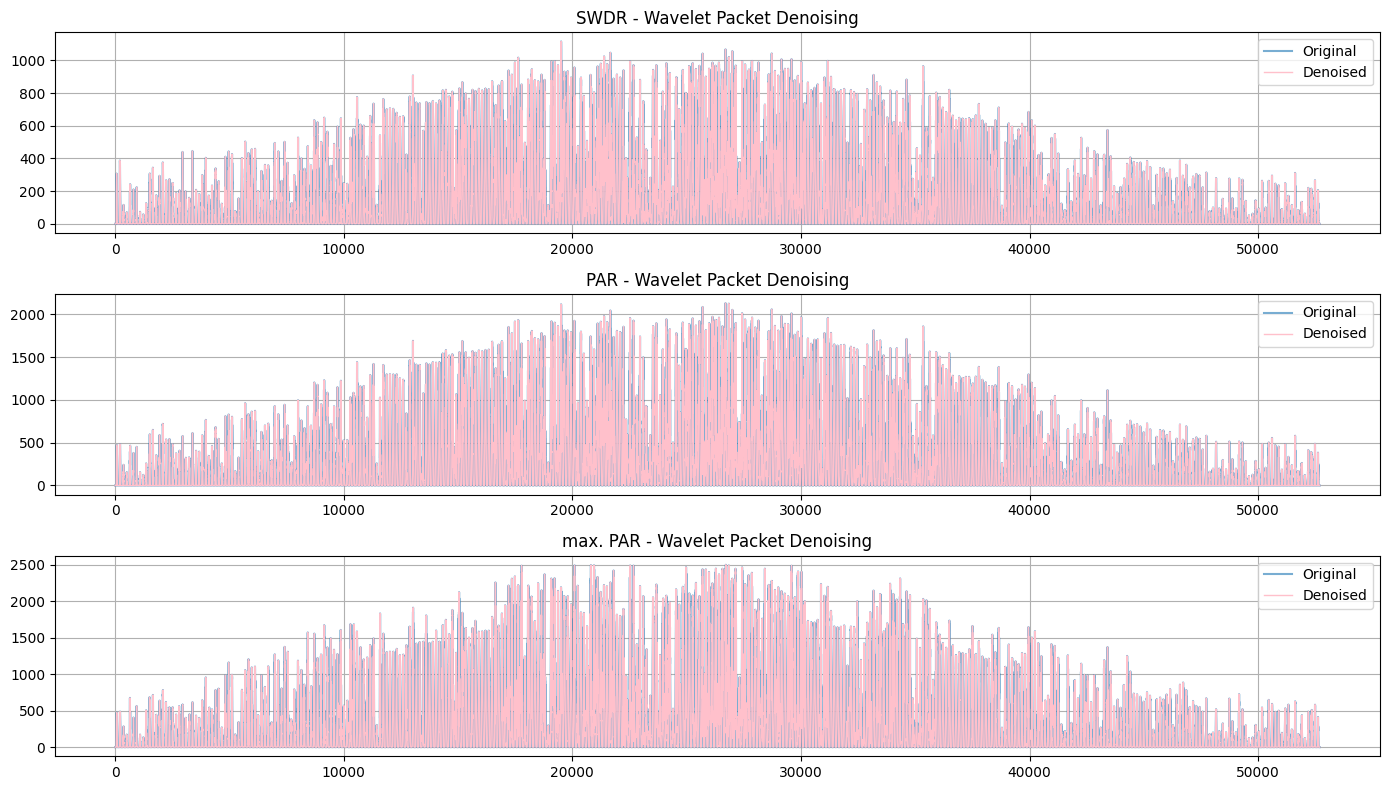

In [15]:
cols = ['SWDR','PAR','max. PAR']

plt.figure(figsize=(14, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.plot(df[col], label='Original', alpha=0.6)
    plt.plot(denoised_df[col], label='Denoised',color='pink', linewidth=1)
    plt.title(f'{col} - Wavelet Packet Denoising')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler
num_cols = denoised_df.select_dtypes(include=['float64','int64']).columns
normalized_df = denoised_df.copy()
normalized_df.head()


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,SWDR,PAR,max. PAR,Tlog,year,month,day,hour,minute,day_of_week
0,2020-01-01 00:10:00,1008.638919,0.362989,272.847861,-1.33,86.1,6.43,5.54,0.89,3.42,...,0.0,0.0,0.0,11.45,2020,1,1,0,10,2
1,2020-01-01 00:20:00,1008.638679,0.354526,272.839396,-1.44,85.2,6.45,5.49,0.95,3.39,...,0.0,0.0,0.0,11.51,2020,1,1,0,20,2
2,2020-01-01 00:30:00,1008.632572,0.344494,272.829780,-1.48,85.1,6.44,5.48,0.96,3.39,...,0.0,0.0,0.0,11.60,2020,1,1,0,30,2
3,2020-01-01 00:40:00,1008.615328,0.322759,272.809300,-1.64,86.3,6.27,5.41,0.86,3.35,...,0.0,0.0,0.0,11.70,2020,1,1,0,40,2
4,2020-01-01 00:50:00,1008.581006,0.297166,272.786021,-1.50,87.4,6.26,5.47,0.79,3.38,...,0.0,0.0,0.0,11.81,2020,1,1,0,50,2


In [17]:
from sklearn.model_selection import train_test_split
# 🔹 MULTI-OUTPUT TARGETS
target_cols = ['T', 'rh', 'rain', 'wv']

In [18]:
# FEATURES
X = normalized_df.drop(columns=['date'] + target_cols)

# MULTI-OUTPUT TARGET
y = normalized_df[target_cols].shift(-1)

In [19]:
X = X.iloc[:-1]
y = y.iloc[:-1]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

base_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xg_model = MultiOutputRegressor(base_model)
xg_model.fit(X_train_scaled, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None


In [23]:
y_pred = xg_model.predict(X_test_scaled)

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error ,r2_score
import numpy as np

def evaluate_multioutput(y_true, y_pred, target_cols):
    for i, col in enumerate(target_cols):
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2 = r2_score(y_true.iloc[:,i], y_pred[:,i])

        print(f" {col} Prediction")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE : {mae:.4f}")
        print(f"R²   : {r2:.4f}")
        print("-" * 30)

In [25]:
evaluate_multioutput(y_test, y_pred, target_cols)

 T Prediction
RMSE: 0.1356
MAE : 0.1017
R²   : 0.9997
------------------------------
 rh Prediction
RMSE: 1.1673
MAE : 0.7654
R²   : 0.9963
------------------------------
 rain Prediction
RMSE: 0.0780
MAE : 0.0103
R²   : 0.1394
------------------------------
 wv Prediction
RMSE: 0.3602
MAE : 0.2599
R²   : 0.9401
------------------------------


In [26]:
import requests
import pandas as pd

In [27]:
API_KEY = "0f05a912eb7a68ac4e6cd9a7df5f1eb8"   # put your real API key here
CITY = "Jena"
COUNTRY = "DE"

In [28]:
import requests
import pandas as pd

def fetch_realtime_weather():
    url = (
        f"https://api.openweathermap.org/data/2.5/weather"
        f"?q={CITY},{COUNTRY}&appid={API_KEY}&units=metric"
    )

    response = requests.get(url)
    data = response.json()

    # Handle API errors
    if response.status_code != 200:
        raise Exception(f"API Error: {data}")

    # Extract real weather values
    temp = data["main"].get("temp", None)
    humidity = data["main"].get("humidity", None)
    pressure = data["main"].get("pressure", None)
    wind_speed = data["wind"].get("speed", None)
    wind_deg = data["wind"].get("deg", None)
    rain_1h = data.get("rain", {}).get("1h", 0)

    # Dew point calculation
    if temp is not None and humidity is not None:
        Tdew = temp - ((100 - humidity) / 5)
    else:
        Tdew = None

    weather_data = {
        "p": pressure,
        "T": temp,
        "rh": humidity,
        "Tdew": Tdew,
        "wv": wind_speed,
        "wd": wind_deg,
        "rain": rain_1h,
        "raining": 1 if rain_1h and rain_1h > 0 else 0
    }

    return pd.DataFrame([weather_data])

In [29]:
import numpy as np
from datetime import datetime

def prepare_features(weather_df, feature_cols):

    df = weather_df.copy()
    # Apply same denoising as training
    for col in df.columns:
        df[col] = df[col].rolling(window=3, min_periods=1).mean()
    # -----------------------------
    # 1. COMPUTE PHYSICS FEATURES
    # -----------------------------

    T = df["T"].values[0]
    rh = df["rh"].values[0]
    p = df["p"].values[0]
    
    if T is not None and rh is not None:

        # Vapor pressure max
        VPmax = 6.11 * np.exp((17.62 * T) / (243.12 + T))

        # Vapor pressure actual
        VPact = (rh / 100.0) * VPmax

        # Vapor pressure deficit
        VPdef = VPmax - VPact

        # Specific humidity approx
        sh = 0.622 * VPact / (df["p"].values[0] - VPact) if df["p"].values[0] else 0

        # Water concentration approx
        H2OC = VPact * 100

        # Air density approx
        rho = df["p"].values[0] / (287.05 * (T + 273.15)) if df["p"].values[0] else 0

        # Log temp
        Tlog = np.log(T + 273.15)
        #Potential Temperature Formula
        Tpot=(T+273.15)*((1000/p)**0.286)
    else:
        VPmax = VPact = VPdef = sh = H2OC = rho = Tlog = Tpot=0

    # Add computed features
    df["VPmax"] = VPmax
    df["VPact"] = VPact
    df["VPdef"] = VPdef
    df["sh"] = sh
    df["H2OC"] = H2OC
    df["rho"] = rho
    df["Tlog"] = Tlog
    df["Tpot"]=Tpot
    # -----------------------------
    # 2. TIME FEATURES
    # -----------------------------
    now = datetime.now()

    df["year"] = now.year
    df["month"] = now.month
    df["day"] = now.day
    df["hour"] = now.hour
    df["minute"] = now.minute
    df["day_of_week"] = now.weekday()

    # -----------------------------
    # 3. ADD MISSING TRAINING FEATURES
    # -----------------------------

    # Some columns existed in training but not API
    df["max. wv"] = df["wv"]
    df["SWDR"] = 0
    df["PAR"] = 0
    df["max. PAR"] = 0

    # -----------------------------
    # 4. ALIGN WITH TRAINING COLUMNS
    # -----------------------------
    df = df.reindex(columns=feature_cols)

    # -----------------------------
    # 5. HANDLE MISSING VALUES
    # -----------------------------
    df = df.fillna(0)

    return df


In [30]:
# Prepare real-time input
realtime_df = fetch_realtime_weather()
X_realtime = prepare_features(realtime_df, X.columns)

# SCALE using training scaler
X_realtime_scaled = scaler.transform(X_realtime)

# MULTI-OUTPUT PREDICTION
predictions_xg =  xg_model.predict(X_realtime_scaled)[0]


In [31]:
pred_T_xg, pred_rh_xg, pred_rain_xg, pred_wv_xg = predictions_xg
print(" Temperature:", round(pred_T_xg, 2), "°C")
print(" Humidity   :", round(pred_rh_xg, 2), "%")
print(" Rain       :", round(pred_rain_xg, 2), "mm")
print(" Wind Speed :", round(pred_wv_xg, 2), "m/s")

 Temperature: 25.03 °C
 Humidity   : 43.19 %
 Rain       : 0.07 mm
 Wind Speed : 2.47 m/s


In [32]:
def infer_weather(T, rh, rain, wv):
    if rain > 0.3:
        return "Rainy "
    elif rh > 85:
        return "Cloudy "
    elif T > 25 and wv < 3:
        return "Sunny "
    else:
        return "Normal "

In [33]:
weather = infer_weather(pred_T_xg, pred_rh_xg, pred_rain_xg, pred_wv_xg)
print("Predicted Weather:", weather)

Predicted Weather: Sunny 


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

lr_model = MultiOutputRegressor(
    LinearRegression()
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("🔹 Linear Regression Results")
evaluate_multioutput(y_test, lr_pred, target_cols)

🔹 Linear Regression Results
 T Prediction
RMSE: 0.1124
MAE : 0.0835
R²   : 0.9998
------------------------------
 rh Prediction
RMSE: 3.0406
MAE : 2.3827
R²   : 0.9748
------------------------------
 rain Prediction
RMSE: 0.0753
MAE : 0.0196
R²   : 0.1988
------------------------------
 wv Prediction
RMSE: 0.5410
MAE : 0.3965
R²   : 0.8649
------------------------------


In [35]:

predictionslr =  lr_model.predict(X_realtime_scaled)[0]

In [36]:
pred_T_lr, pred_rh_lr, pred_rain_lr, pred_wv_lr = predictionslr

print(" Temperature:", round(pred_T_lr, 2), "°C")
print(" Humidity   :", round(pred_rh_lr, 2), "%")
print(" Rain       :", round(pred_rain_lr, 2), "mm")
print(" Wind Speed :", round(pred_wv_lr, 2), "m/s")

 Temperature: 1563.51 °C
 Humidity   : -29572.22 %
 Rain       : 93.77 mm
 Wind Speed : -108.79 m/s


In [37]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor

knn_model = MultiOutputRegressor(
    KNeighborsRegressor(
        n_neighbors=5,
        weights='distance'
    )
)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print(" KNN Results")
evaluate_multioutput(y_test, knn_pred, target_cols)

 KNN Results
 T Prediction
RMSE: 0.5231
MAE : 0.3731
R²   : 0.9951
------------------------------
 rh Prediction
RMSE: 2.6978
MAE : 1.8944
R²   : 0.9802
------------------------------
 rain Prediction
RMSE: 0.0861
MAE : 0.0098
R²   : -0.0492
------------------------------
 wv Prediction
RMSE: 0.3373
MAE : 0.2228
R²   : 0.9475
------------------------------


In [38]:
predictionsknn =  knn_model.predict(X_realtime_scaled)[0]

In [39]:
pred_T_knn, pred_rh_knn, pred_rain_knn, pred_wv_knn = predictionsknn

print(" Temperature:", round(pred_T_knn, 2), "°C")
print(" Humidity   :", round(pred_rh_knn, 2), "%")
print(" Rain       :", round(pred_rain_knn, 2), "mm")
print(" Wind Speed :", round(pred_wv_knn, 2), "m/s")

 Temperature: 22.18 °C
 Humidity   : 88.38 %
 Rain       : 0.0 mm
 Wind Speed : 0.61 m/s


In [40]:
weather = infer_weather(pred_T_knn, pred_rh_knn, pred_rain_knn, pred_wv_knn)
print("Predicted Weather:", weather)

Predicted Weather: Cloudy 


In [41]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

lgbm_base = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

lgbm_model = MultiOutputRegressor(lgbm_base)

lgbm_model.fit(X_train_scaled, y_train)

lgbm_pred = lgbm_model.predict(X_test_scaled)

print(" LightGBM Results")
evaluate_multioutput(y_test, lgbm_pred, target_cols)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003794 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3972
[LightGBM] [Info] Number of data points in the train set: 42156, number of used features: 21
[LightGBM] [Info] Start training from score 10.690393
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014816 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3972
[LightGBM] [Info] Number of data points in the train set: 42156, number of used features: 21
[LightGBM] [Info] Start training from score 72.487558
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004042 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3972
[LightGBM] [Info] Number of data points in the train set: 42156, number of used features: 21
[LightGBM] [Info] Start t

C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [42]:
# Prepare real-time input
realtime_df = fetch_realtime_weather()
X_realtime = prepare_features(realtime_df, X.columns)

## SCALE using training scaler
X_realtime_scaled = scaler.transform(X_realtime)

# Convert back to DataFrame with the same column names
X_realtime_scaled = pd.DataFrame(X_realtime_scaled, columns=X.columns)

# MULTI-OUTPUT PREDICTION
predictionslgbm = lgbm_model.predict(X_realtime_scaled)[0]

In [43]:
pred_T_lgbm, pred_rh_lgbm, pred_rain_lgbm, pred_wv_lgbm = predictionslgbm
print("Temperature Predicted by LightGBM:")
print("Temperature:", round(pred_T_lgbm, 2), "°C")
print("Humidity   :", round(pred_rh_lgbm, 2), "%")
print("Rain       :", round(pred_rain_lgbm, 2), "mm")
print("Wind Speed :", round(pred_wv_lgbm, 2), "m/s")

Temperature Predicted by LightGBM:
Temperature: 25.09 °C
Humidity   : 39.83 %
Rain       : 0.01 mm
Wind Speed : 0.78 m/s


In [44]:
weather = infer_weather(pred_T_lgbm, pred_rh_lgbm, pred_rain_lgbm, pred_wv_lgbm)
print(" Predicted Weather:", weather)

 Predicted Weather: Sunny 


In [45]:
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor

cat_base = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=0,
    random_state=42
)

cat_model = MultiOutputRegressor(cat_base)

cat_model.fit(X_train_scaled, y_train)

cat_pred = cat_model.predict(X_test_scaled)

print(" CatBoost Results")
evaluate_multioutput(y_test, cat_pred, target_cols)

 CatBoost Results
 T Prediction
RMSE: 0.1924
MAE : 0.1484
R²   : 0.9993
------------------------------
 rh Prediction
RMSE: 1.2158
MAE : 0.8155
R²   : 0.9960
------------------------------
 rain Prediction
RMSE: 0.0659
MAE : 0.0103
R²   : 0.3849
------------------------------
 wv Prediction
RMSE: 0.4543
MAE : 0.3332
R²   : 0.9047
------------------------------


In [46]:
# Prepare real-time input
realtime_df = fetch_realtime_weather()
X_realtime = prepare_features(realtime_df, X.columns)

# SCALE using training scaler
X_realtime_scaled = scaler.transform(X_realtime)

# MULTI-OUTPUT PREDICTION
predictionscat =  cat_model.predict(X_realtime_scaled)[0]

In [47]:
pred_T_cat, pred_rh_cat, pred_rain_cat, pred_wv_cat = predictionscat
print("Temperature Predicted by CatBoost:")
print("Temperature:", round(pred_T_cat, 2), "°C")
print("Humidity   :", round(pred_rh_cat, 2), "%")
print("Rain       :", round(pred_rain_cat, 2), "mm")
print("Wind Speed :", round(pred_wv_cat, 2), "m/s")

Temperature Predicted by CatBoost:
Temperature: 18.94 °C
Humidity   : 47.86 %
Rain       : 0.01 mm
Wind Speed : 0.89 m/s


In [48]:
weather = infer_weather(pred_T_cat , pred_rh_cat, pred_rain_cat, pred_wv_cat)
print("Predicted Weather:", weather)

Predicted Weather: Normal 


In [49]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import MultiOutputRegressor

ada_base = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_model = MultiOutputRegressor(ada_base)

ada_model.fit(X_train_scaled, y_train)

ada_pred = ada_model.predict(X_test_scaled)

print("AdaBoost Results")
evaluate_multioutput(y_test, ada_pred, target_cols)

AdaBoost Results
 T Prediction
RMSE: 0.2791
MAE : 0.2147
R²   : 0.9986
------------------------------
 rh Prediction
RMSE: 2.5993
MAE : 1.9324
R²   : 0.9816
------------------------------
 rain Prediction
RMSE: 0.0907
MAE : 0.0212
R²   : -0.1646
------------------------------
 wv Prediction
RMSE: 0.5324
MAE : 0.4000
R²   : 0.8692
------------------------------


In [50]:
# Prepare real-time input
realtime_df = fetch_realtime_weather()
X_realtime = prepare_features(realtime_df, X.columns)

# SCALE using training scaler
X_realtime_scaled = scaler.transform(X_realtime)

# MULTI-OUTPUT PREDICTION
predictionsada =  ada_model.predict(X_realtime_scaled)[0]

In [51]:
pred_T_ada, pred_rh_ada, pred_rain_ada, pred_wv_ada = predictionsada
print("Temperature Predicted by AdaBoost:")
print("Temperature:", round(pred_T_ada, 2), "°C")
print("Humidity   :", round(pred_rh_ada, 2), "%")
print("Rain       :", round(pred_rain_ada, 2), "mm")
print("Wind Speed :", round(pred_wv_ada, 2), "m/s")

Temperature Predicted by AdaBoost:
Temperature: 26.37 °C
Humidity   : 43.51 %
Rain       : 0.01 mm
Wind Speed : 0.35 m/s


In [52]:
def infer_weather(T, rh, rain, wv):
    if rain > 0.3:
        return "Rainy"
    elif rh > 85:
        return "Cloudy"
    elif T > 25 and wv < 3:
        return "Sunny"
    else:
        return "Normal"

weather = infer_weather(pred_T_ada , pred_rh_ada, pred_rain_ada, pred_wv_ada)
print("Predicted Weather:", weather)

Predicted Weather: Sunny


In [53]:
print("REALTIME FEATURES GIVEN TO MODEL:")
print(X_realtime.T)

REALTIME FEATURES GIVEN TO MODEL:
                       0
p            1031.000000
Tpot          297.173909
Tdew           15.630000
VPmax          34.792139
VPact          15.656462
VPdef          19.135676
sh              0.009591
H2OC         1565.646243
rho             0.011981
max. wv         0.890000
wd             38.000000
raining         0.000000
SWDR            0.000000
PAR             0.000000
max. PAR        0.000000
Tlog            5.703049
year         2026.000000
month           5.000000
day            25.000000
hour           20.000000
minute         24.000000
day_of_week     0.000000


In [54]:
from sklearn.svm import LinearSVR
from sklearn.multioutput import MultiOutputRegressor

svr_model = MultiOutputRegressor(
    LinearSVR(
        C=1.0,
        epsilon=0.1,
        max_iter=5000,
        random_state=42
    )
)

svr_model.fit(X_train_scaled, y_train)

svr_pred = svr_model.predict(X_test_scaled)

print(" LinearSVR Results")
evaluate_multioutput(y_test, svr_pred, target_cols)

C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


 LinearSVR Results
 T Prediction
RMSE: 0.1125
MAE : 0.0836
R²   : 0.9998
------------------------------
 rh Prediction
RMSE: 3.2207
MAE : 2.2697
R²   : 0.9717
------------------------------
 rain Prediction
RMSE: 0.0853
MAE : 0.0440
R²   : -0.0304
------------------------------
 wv Prediction
RMSE: 0.5439
MAE : 0.3954
R²   : 0.8635
------------------------------


In [55]:
# Prepare real-time input
realtime_df = fetch_realtime_weather()
X_realtime = prepare_features(realtime_df, X.columns)

# Scale using training scaler
X_realtime_scaled = scaler.transform(X_realtime)

# Multi-output prediction
predictions_svr = svr_model.predict(X_realtime_scaled)[0]

In [56]:
pred_T_svr, pred_rh_svr, pred_rain_svr, pred_wv_svr = predictions_svr
print("Temperature Predicted by SVR:")
print("Temperature:", round(pred_T_svr, 2), "°C")
print("Humidity   :", round(pred_rh_svr, 2), "%")
print("Rain       :", round(pred_rain_svr, 2), "mm")
print("Wind Speed :", round(pred_wv_svr, 2), "m/s")


Temperature Predicted by SVR:
Temperature: 333.86 °C
Humidity   : -1374.48 %
Rain       : 50.71 mm
Wind Speed : 267.88 m/s


In [57]:
weather_svr = infer_weather(pred_T_svr, pred_rh_svr, pred_rain_svr, pred_wv_svr)
print("Predicted Weather:", weather_svr)

Predicted Weather: Rainy


In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

rf_model = MultiOutputRegressor(
    RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
)

# You can use either X_train or X_train_scaled; using scaled keeps things consistent
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

print(" Random Forest Results")
evaluate_multioutput(y_test, rf_pred, target_cols)

 Random Forest Results
 T Prediction
RMSE: 0.1812
MAE : 0.1362
R²   : 0.9994
------------------------------
 rh Prediction
RMSE: 1.3039
MAE : 0.8399
R²   : 0.9954
------------------------------
 rain Prediction
RMSE: 0.0711
MAE : 0.0098
R²   : 0.2857
------------------------------
 wv Prediction
RMSE: 0.4637
MAE : 0.3356
R²   : 0.9007
------------------------------


In [59]:
# Prepare real-time input
realtime_df = fetch_realtime_weather()
X_realtime = prepare_features(realtime_df, X.columns)
X_realtime_scaled = scaler.transform(X_realtime)

predictions_rf = rf_model.predict(X_realtime_scaled)[0]
pred_T_rf, pred_rh_rf, pred_rain_rf, pred_wv_rf = predictions_rf
print("Temperature Predicted by Random Forest:")
print(" Temperature (RF):", round(pred_T_rf, 2), "°C")
print(" Humidity   (RF):", round(pred_rh_rf, 2), "%")
print(" Rain       (RF):", round(pred_rain_rf, 2), "mm")
print(" Wind Speed (RF):", round(pred_wv_rf, 2), "m/s")

weather_rf = infer_weather(pred_T_rf, pred_rh_rf, pred_rain_rf, pred_wv_rf)
print("Predicted Weather (RF):", weather_rf)

Temperature Predicted by Random Forest:
 Temperature (RF): 26.39 °C
 Humidity   (RF): 45.74 %
 Rain       (RF): 0.79 mm
 Wind Speed (RF): 0.4 m/s
Predicted Weather (RF): Rainy


In [60]:
xgb_pred  = xg_model.predict(X_test_scaled)
lr_pred   = lr_model.predict(X_test_scaled)
knn_pred  = knn_model.predict(X_test_scaled)
lgbm_pred = lgbm_model.predict(X_test_scaled)
cat_pred  = cat_model.predict(X_test_scaled)
ada_pred  = ada_model.predict(X_test_scaled)
svr_pred  = svr_model.predict(X_test_scaled)
rf_pred   = rf_model.predict(X_test_scaled)

C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [61]:
from sklearn.metrics import mean_squared_error
import numpy as np

# All models and their test predictions
model_names = ["XGBoost", "KNN", "LightGBM", 
               "CatBoost", "AdaBoost", "RandomForest"]

all_preds   = [xgb_pred,  knn_pred, lgbm_pred,
               cat_pred, ada_pred, rf_pred]

# Compute RMSE for each model for each target
rmse_table = {}
for name, pred in zip(model_names, all_preds):
    rmse_per_target = []
    for i in range(len(target_cols)):
        rmse = np.sqrt(mean_squared_error(
                   y_test.iloc[:, i], pred[:, i]))
        rmse_per_target.append(rmse)
    rmse_table[name] = rmse_per_target

# Display RMSE table
import pandas as pd
rmse_df = pd.DataFrame(rmse_table, index=target_cols).T
rmse_df.columns = target_cols
print(" RMSE Table (rows=models, cols=targets):")
print(rmse_df.round(4).to_string())

 RMSE Table (rows=models, cols=targets):
                   T      rh    rain      wv
XGBoost       0.1356  1.1673  0.0780  0.3602
KNN           0.5231  2.6978  0.0861  0.3373
LightGBM      0.1703  1.1896  0.0655  0.4284
CatBoost      0.1924  1.2158  0.0659  0.4543
AdaBoost      0.2791  2.5993  0.0907  0.5324
RandomForest  0.1812  1.3039  0.0711  0.4637


In [62]:
# ── WEIGHTED ENSEMBLE ────────────────────────────────────
# Weight = 1/RMSE (lower RMSE = higher weight)
# Weights normalized so they sum to 1 for each target

weighted_ensemble_pred = np.zeros_like(xgb_pred)

ensemble_weights = {}  # store weights for later use

print("  Weights per Target:")
print("=" * 55)

for i, col in enumerate(target_cols):
    # Get RMSE of each model for this target
    rmse_vals = np.array([rmse_table[m][i] for m in model_names])

    # Inverse RMSE
    inv_rmse = 1.0 / (rmse_vals + 1e-8)

    # Normalize so weights sum to 1
    weights = inv_rmse / inv_rmse.sum()

    # Store weights
    ensemble_weights[col] = {m: float(w) 
                             for m, w in zip(model_names, weights)}

    print(f"\n Target: {col}")
    for m, w in zip(model_names, weights):
        bar = "|" * int(w * 40)
        print(f"   {m:14s}: {w:.4f}  {bar}")

    # Compute weighted prediction for this target
    for j, pred in enumerate(all_preds):
        weighted_ensemble_pred[:, i] += weights[j] * pred[:, i]

print("\n Weighted Ensemble predictions computed!")

  Weights per Target:

 Target: T
   XGBoost       : 0.2504  ||||||||||
   KNN           : 0.0649  ||
   LightGBM      : 0.1994  |||||||
   CatBoost      : 0.1765  |||||||
   AdaBoost      : 0.1216  ||||
   RandomForest  : 0.1873  |||||||

 Target: rh
   XGBoost       : 0.2119  ||||||||
   KNN           : 0.0917  |||
   LightGBM      : 0.2080  ||||||||
   CatBoost      : 0.2035  ||||||||
   AdaBoost      : 0.0952  |||
   RandomForest  : 0.1897  |||||||

 Target: rain
   XGBoost       : 0.1604  ||||||
   KNN           : 0.1452  |||||
   LightGBM      : 0.1909  |||||||
   CatBoost      : 0.1897  |||||||
   AdaBoost      : 0.1378  |||||
   RandomForest  : 0.1760  |||||||

 Target: wv
   XGBoost       : 0.1940  |||||||
   KNN           : 0.2072  ||||||||
   LightGBM      : 0.1631  ||||||
   CatBoost      : 0.1538  ||||||
   AdaBoost      : 0.1312  |||||
   RandomForest  : 0.1507  ||||||

 Weighted Ensemble predictions computed!


In [63]:
# ── EVALUATE WEIGHTED ENSEMBLE ───────────────────────────

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "=" * 50)
print("     WEIGHTED ENSEMBLE RESULTS")
print("=" * 50)

for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(
               y_test.iloc[:, i], 
               weighted_ensemble_pred[:, i]))
    mae  = mean_absolute_error(
               y_test.iloc[:, i], 
               weighted_ensemble_pred[:, i])
    r2   = r2_score(
               y_test.iloc[:, i], 
               weighted_ensemble_pred[:, i])

    print(f"\n {col}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}")

print("\n" + "=" * 50)


     WEIGHTED ENSEMBLE RESULTS

 T
   RMSE : 0.1570
   MAE  : 0.1192
   R²   : 0.9996

 rh
   RMSE : 1.1627
   MAE  : 0.7742
   R²   : 0.9963

 rain
   RMSE : 0.0670
   MAE  : 0.0105
   R²   : 0.3649

 wv
   RMSE : 0.3800
   MAE  : 0.2768
   R²   : 0.9334



In [64]:
# ── FULL MODEL COMPARISON TABLE ──────────────────────────

comparison_rows = []

# Individual models
for name, pred in zip(model_names, all_preds):
    for i, col in enumerate(target_cols):
        rmse = np.sqrt(mean_squared_error(
                   y_test.iloc[:, i], pred[:, i]))
        mae  = mean_absolute_error(
                   y_test.iloc[:, i], pred[:, i])
        r2   = r2_score(
                   y_test.iloc[:, i], pred[:, i])
        comparison_rows.append({
            "Model":  name,
            "Target": col,
            "RMSE":   round(rmse, 4),
            "MAE":    round(mae,  4),
            "R²":     round(r2,   4)
        })

# Weighted ensemble
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(
               y_test.iloc[:, i], 
               weighted_ensemble_pred[:, i]))
    mae  = mean_absolute_error(
               y_test.iloc[:, i], 
               weighted_ensemble_pred[:, i])
    r2   = r2_score(
               y_test.iloc[:, i], 
               weighted_ensemble_pred[:, i])
    comparison_rows.append({
        "Model":  "WeightedEnsemble",
        "Target": col,
        "RMSE":   round(rmse, 4),
        "MAE":    round(mae,  4),
        "R²":     round(r2,   4)
    })

comp_df = pd.DataFrame(comparison_rows)

# Pivot RMSE
print(" RMSE Comparison (lower is better):")
pivot_rmse = comp_df.pivot(index="Model", 
                            columns="Target", 
                            values="RMSE")
print(pivot_rmse.to_string())

print("\n R² Comparison (higher is better):")
pivot_r2 = comp_df.pivot(index="Model", 
                          columns="Target", 
                          values="R²")
print(pivot_r2.to_string())

 RMSE Comparison (lower is better):
Target                 T    rain      rh      wv
Model                                           
AdaBoost          0.2791  0.0907  2.5993  0.5324
CatBoost          0.1924  0.0659  1.2158  0.4543
KNN               0.5231  0.0861  2.6978  0.3373
LightGBM          0.1703  0.0655  1.1896  0.4284
RandomForest      0.1812  0.0711  1.3039  0.4637
WeightedEnsemble  0.1570  0.0670  1.1627  0.3800
XGBoost           0.1356  0.0780  1.1673  0.3602

 R² Comparison (higher is better):
Target                 T    rain      rh      wv
Model                                           
AdaBoost          0.9986 -0.1646  0.9816  0.8692
CatBoost          0.9993  0.3849  0.9960  0.9047
KNN               0.9951 -0.0492  0.9802  0.9475
LightGBM          0.9995  0.3929  0.9961  0.9153
RandomForest      0.9994  0.2857  0.9954  0.9007
WeightedEnsemble  0.9996  0.3649  0.9963  0.9334
XGBoost           0.9997  0.1394  0.9963  0.9401


C:\Users\Maithili\AppData\Local\Temp\ipykernel_36704\4253250496.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(all_model_names_plot,
C:\Users\Maithili\AppData\Local\Temp\ipykernel_36704\4253250496.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(all_model_names_plot,
C:\Users\Maithili\AppData\Local\Temp\ipykernel_36704\4253250496.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(all_model_names_plot,
C:\Users\Maithili\AppData\Local\Temp\ipykernel_36704\4253250496.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(all_model_names_plot,


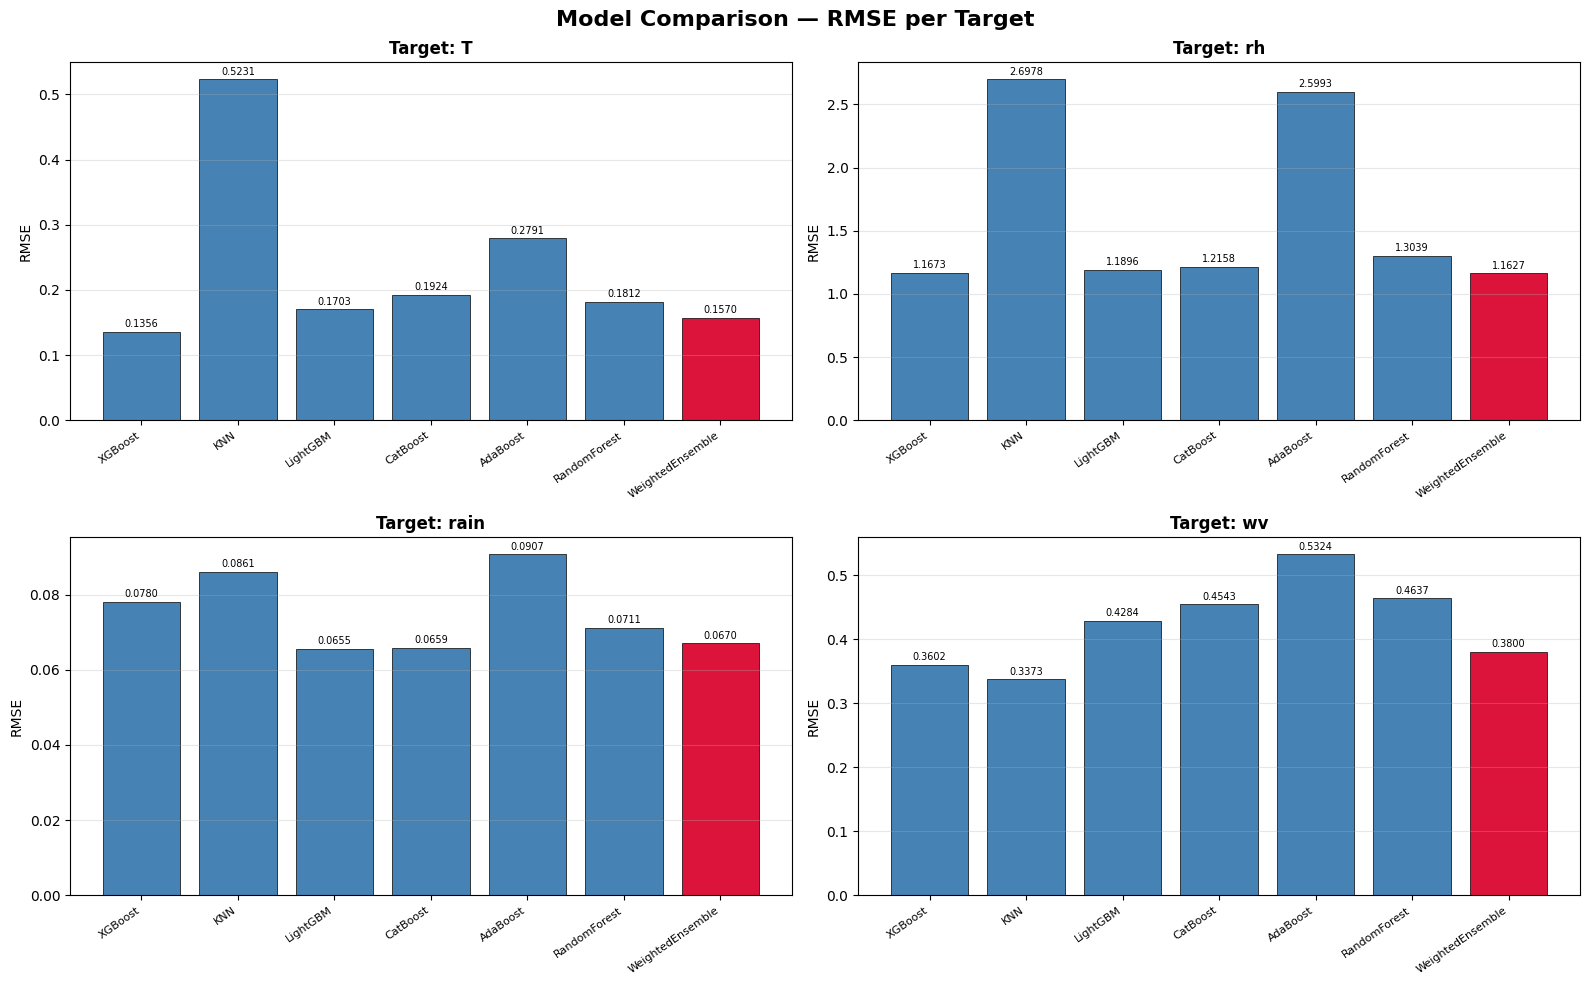

 Chart saved as model_comparison_rmse.png


In [65]:
# ── RMSE BAR CHART ───────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Model Comparison — RMSE per Target", 
             fontsize=16, fontweight="bold")

all_model_names_plot = model_names + ["WeightedEnsemble"]

# Highlight ensemble bar in red
colors = ["steelblue"] * len(model_names) + ["crimson"]

for ax, col in zip(axes.flatten(), target_cols):
    rmse_vals = []
    for m in all_model_names_plot:
        row = comp_df[(comp_df["Model"]  == m) & 
                      (comp_df["Target"] == col)]
        rmse_vals.append(float(row["RMSE"].values[0]))

    bars = ax.bar(all_model_names_plot, rmse_vals, 
                  color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(f"Target: {col}", fontsize=12, fontweight="bold")
    ax.set_ylabel("RMSE")
    ax.set_xticklabels(all_model_names_plot, 
                       rotation=35, ha="right", fontsize=8)
    ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison_rmse.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart saved as model_comparison_rmse.png")

In [66]:
# ── REAL-TIME WEIGHTED ENSEMBLE PREDICTION ───────────────

realtime_df       = fetch_realtime_weather()
X_realtime        = prepare_features(realtime_df, X.columns)
X_realtime_scaled = scaler.transform(X_realtime)

# Get predictions from 6 models
rt_preds = {
    "XGBoost":      xg_model.predict(X_realtime_scaled)[0],
    "KNN":          knn_model.predict(X_realtime_scaled)[0],
    "LightGBM":     lgbm_model.predict(X_realtime_scaled)[0],
    "CatBoost":     cat_model.predict(X_realtime_scaled)[0],
    "AdaBoost":     ada_model.predict(X_realtime_scaled)[0],
    "RandomForest": rf_model.predict(X_realtime_scaled)[0]
}

# Apply ensemble weights
final_pred = np.zeros(len(target_cols))

for i, col in enumerate(target_cols):
    for m_name, w in ensemble_weights[col].items():
        final_pred[i] += w * rt_preds[m_name][i]

pred_T    = round(float(final_pred[0]), 2)
pred_rh   = round(float(final_pred[1]), 2)
pred_rain = round(float(final_pred[2]), 2)
pred_wv   = round(float(final_pred[3]), 2)

print("=" * 40)
print("    WEIGHTED ENSEMBLE — NEXT 10 MIN")
print("=" * 40)
print(f"  Temperature : {pred_T}  °C")
print(f"  Humidity    : {pred_rh}  %")
print(f"  Rain        : {pred_rain}  mm")
print(f"  Wind Speed  : {pred_wv}  m/s")
print("=" * 40)


C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


    WEIGHTED ENSEMBLE — NEXT 10 MIN
  Temperature : 24.19  °C
  Humidity    : 48.14  %
  Rain        : 0.15  mm
  Wind Speed  : 0.98  m/s


In [67]:
# ── WEATHER CONDITION ────────────────────────────────────

def infer_weather_ensemble(T, rh, rain, wv):
    if rain > 0.3:
        return "Rainy"
    elif rh > 85:
        return "Cloudy"
    elif T > 25 and wv < 3:
        return "Sunny"
    elif T < 5:
        return "Cold"
    else:
        return "Normal"

condition = infer_weather_ensemble(pred_T, pred_rh, 
                                   pred_rain, pred_wv)
print("Predicted Condition (next 10 min):", condition)

Predicted Condition (next 10 min): Normal


In [68]:
# ── STACKING — STEP 1: BUILD META-FEATURES ───────────────
# We use TRAIN predictions for fitting meta-learner
# and TEST predictions for evaluating it

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict
import numpy as np

print(" Building meta-features from all 8 models...")

# Use only top 3 models
stack_model_names = ["XGBoost", "LightGBM", "RandomForest"]

stack_all_preds_test  = [xgb_pred, lgbm_pred, rf_pred]

stack_all_preds_train = [
    xg_model.predict(X_train_scaled),
    lgbm_model.predict(X_train_scaled),
    rf_model.predict(X_train_scaled)
]

# Stack predictions → shape: (n_samples, 8*4) = (n, 32)
# Each model contributes 4 predictions (T, rh, rain, wv)
meta_train = np.hstack(stack_all_preds_train)
meta_test  = np.hstack(stack_all_preds_test)

print(f" Meta-feature matrix shape (train): {meta_train.shape}")
print(f" Meta-feature matrix shape (test) : {meta_test.shape}")
print(f"   Meaning: {len(stack_model_names)} models × {len(target_cols)} targets = {len(stack_model_names)*len(target_cols)} meta-features")

 Building meta-features from all 8 models...


C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


 Meta-feature matrix shape (train): (42156, 12)
 Meta-feature matrix shape (test) : (10539, 12)
   Meaning: 3 models × 4 targets = 12 meta-features


In [69]:
# ── STACKING — STEP 2: TRAIN META-LEARNER ────────────────
# Ridge Regression learns optimal combination of 
# all 8 model predictions

from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

print(" Training Ridge meta-learner...")

meta_learner = MultiOutputRegressor(
    Ridge(alpha=1.0)
)

meta_learner.fit(meta_train, y_train)

print("\n Meta-learner trained successfully!")
print("   Meta-learner: Ridge Regression (alpha=1.0)")
print(f"   Input  : {meta_train.shape[1]} meta-features")
print(f"   Output : {len(target_cols)} targets {target_cols}")

 Training Ridge meta-learner...

 Meta-learner trained successfully!
   Meta-learner: Ridge Regression (alpha=1.0)
   Input  : 12 meta-features
   Output : 4 targets ['T', 'rh', 'rain', 'wv']


In [70]:
# ── STACKING — STEP 3: PREDICT ON TEST SET ───────────────

stacking_pred = meta_learner.predict(meta_test)

print(" Stacking predictions computed!")
print(f"   Shape: {stacking_pred.shape}")

 Stacking predictions computed!
   Shape: (10539, 4)


In [71]:
# ── STACKING — STEP 4: EVALUATE ──────────────────────────

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "=" * 50)
print("     HYBRID STACKING RESULTS")
print("=" * 50)

for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(
               y_test.iloc[:, i],
               stacking_pred[:, i]))
    mae  = mean_absolute_error(
               y_test.iloc[:, i],
               stacking_pred[:, i])
    r2   = r2_score(
               y_test.iloc[:, i],
               stacking_pred[:, i])

    print(f"\n {col}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}")

print("\n" + "=" * 50)


     HYBRID STACKING RESULTS

 T
   RMSE : 0.1341
   MAE  : 0.0994
   R²   : 0.9997

 rh
   RMSE : 1.1981
   MAE  : 0.7953
   R²   : 0.9961

 rain
   RMSE : 0.0810
   MAE  : 0.0107
   R²   : 0.0710

 wv
   RMSE : 0.3486
   MAE  : 0.2502
   R²   : 0.9439



In [72]:
# ── STACKING — STEP 4: EVALUATE ──────────────────────────

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "=" * 50)
print("     HYBRID STACKING RESULTS")
print("=" * 50)

for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(
               y_test.iloc[:, i],
               stacking_pred[:, i]))
    mae  = mean_absolute_error(
               y_test.iloc[:, i],
               stacking_pred[:, i])
    r2   = r2_score(
               y_test.iloc[:, i],
               stacking_pred[:, i])

    print(f"\n {col}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}")

print("\n" + "=" * 50)


     HYBRID STACKING RESULTS

 T
   RMSE : 0.1341
   MAE  : 0.0994
   R²   : 0.9997

 rh
   RMSE : 1.1981
   MAE  : 0.7953
   R²   : 0.9961

 rain
   RMSE : 0.0810
   MAE  : 0.0107
   R²   : 0.0710

 wv
   RMSE : 0.3486
   MAE  : 0.2502
   R²   : 0.9439



In [73]:
# ── FULL COMPARISON: Individual vs Ensemble vs Hybrid ────

import pandas as pd

print("\n" + "=" * 65)
print("   COMPARISON: Individual vs Weighted Ensemble vs Hybrid")
print("=" * 65)
print(f"{'Model':<20} {'Target':<8} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 65)

# Best individual model (XGBoost) for reference
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], xgb_pred[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], xgb_pred[:, i])
    r2   = r2_score(y_test.iloc[:, i], xgb_pred[:, i])
    print(f"{'XGBoost(best)':<20} {col:<8} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

print("-" * 65)

# Weighted ensemble
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], weighted_ensemble_pred[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], weighted_ensemble_pred[:, i])
    r2   = r2_score(y_test.iloc[:, i], weighted_ensemble_pred[:, i])
    print(f"{'WeightedEnsemble':<20} {col:<8} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

print("-" * 65)

# Hybrid stacking
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], stacking_pred[:, i])
    r2   = r2_score(y_test.iloc[:, i], stacking_pred[:, i])
    print(f"{'HybridStacking':<20} {col:<8} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

print("=" * 65)


   COMPARISON: Individual vs Weighted Ensemble vs Hybrid
Model                Target       RMSE      MAE       R²
-----------------------------------------------------------------
XGBoost(best)        T          0.1356   0.1017   0.9997
XGBoost(best)        rh         1.1673   0.7654   0.9963
XGBoost(best)        rain       0.0780   0.0103   0.1394
XGBoost(best)        wv         0.3602   0.2599   0.9401
-----------------------------------------------------------------
WeightedEnsemble     T          0.1570   0.1192   0.9996
WeightedEnsemble     rh         1.1627   0.7742   0.9963
WeightedEnsemble     rain       0.0670   0.0105   0.3649
WeightedEnsemble     wv         0.3800   0.2768   0.9334
-----------------------------------------------------------------
HybridStacking       T          0.1341   0.0994   0.9997
HybridStacking       rh         1.1981   0.7953   0.9961
HybridStacking       rain       0.0810   0.0107   0.0710
HybridStacking       wv         0.3486   0.2502   0.9439


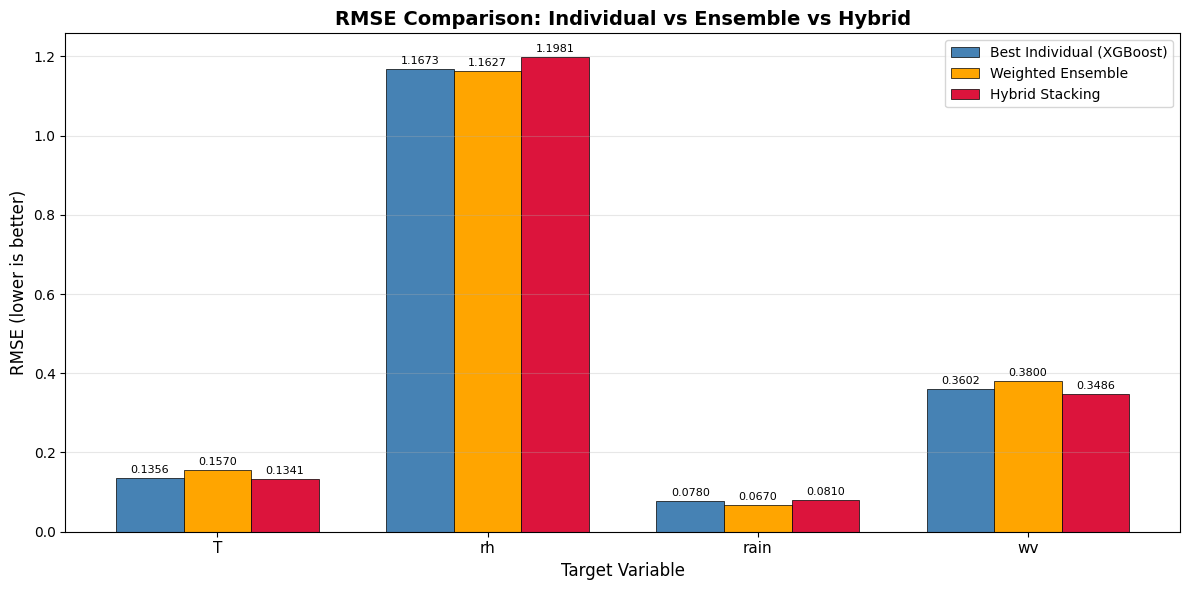

 Chart saved as hybrid_comparison.png


In [74]:
# ── VISUALIZATION: RMSE Comparison All 3 Levels ──────────
import matplotlib.pyplot as plt
import numpy as np

labels = target_cols
x      = np.arange(len(labels))
width  = 0.25

# Compute RMSE for each level
xgb_rmse      = [np.sqrt(mean_squared_error(y_test.iloc[:, i], xgb_pred[:, i]))
                  for i in range(len(target_cols))]
ensemble_rmse  = [np.sqrt(mean_squared_error(y_test.iloc[:, i], weighted_ensemble_pred[:, i]))
                  for i in range(len(target_cols))]
stacking_rmse  = [np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred[:, i]))
                  for i in range(len(target_cols))]

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, xgb_rmse,     width, label="Best Individual (XGBoost)",
               color="steelblue",  edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x,          ensemble_rmse, width, label="Weighted Ensemble",
               color="orange",     edgecolor="black", linewidth=0.5)
bars3 = ax.bar(x + width,  stacking_rmse, width, label="Hybrid Stacking",
               color="crimson",    edgecolor="black", linewidth=0.5)

ax.set_xlabel("Target Variable", fontsize=12)
ax.set_ylabel("RMSE (lower is better)", fontsize=12)
ax.set_title("RMSE Comparison: Individual vs Ensemble vs Hybrid",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=10)
ax.bar_label(bars1, fmt="%.4f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.4f", padding=2, fontsize=8)
ax.bar_label(bars3, fmt="%.4f", padding=2, fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("hybrid_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart saved as hybrid_comparison.png")

In [75]:
# ── REAL-TIME HYBRID STACKING PREDICTION ─────────────────

realtime_df       = fetch_realtime_weather()
X_realtime        = prepare_features(realtime_df, X.columns)
X_realtime_scaled = scaler.transform(X_realtime)

# Step 1 — get all 8 base model predictions
rt_base_preds = [
    xg_model.predict(X_realtime_scaled),
    lgbm_model.predict(X_realtime_scaled),
    rf_model.predict(X_realtime_scaled)
]

# Step 2 — stack into meta-features
meta_realtime = np.hstack(rt_base_preds)

# Step 3 — meta-learner predicts final output
hybrid_final = meta_learner.predict(meta_realtime)[0]

# Store with unique variable names
hybrid_T    = round(float(hybrid_final[0]), 2)
hybrid_rh   = round(float(hybrid_final[1]), 2)
hybrid_rain = round(float(hybrid_final[2]), 2)
hybrid_wv   = round(float(hybrid_final[3]), 2)

print("=" * 45)
print("    HYBRID STACKING OF THREE MODELS — NEXT 10 MIN")
print("=" * 45)
print(f"  Temperature : {hybrid_T} °C")
print(f"  Humidity    : {hybrid_rh} %")
print(f"  Rain        : {hybrid_rain} mm")
print(f"  Wind Speed  : {hybrid_wv} m/s")
print("=" * 45)

    HYBRID STACKING OF THREE MODELS — NEXT 10 MIN
  Temperature : 24.93 °C
  Humidity    : 45.68 %
  Rain        : 0.02 mm
  Wind Speed  : 3.54 m/s


C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [76]:
condition = infer_weather(hybrid_T, hybrid_rh, hybrid_rain, hybrid_wv)
print(f"  Condition   : {condition}")
print("=" * 45)

  Condition   : Normal


In [77]:
print(" Building meta-features from all 8 models...")

# All 6f models and their predictions on TEST SET
stack_model_names_e = ["XGBoost", "KNN", "LightGBM",
                     "CatBoost", "AdaBoost", "RandomForest"]

stack_all_preds_test_e = [xgb_pred, knn_pred, lgbm_pred,
                        cat_pred, ada_pred, rf_pred]

# All 6f models predictions on TRAIN SET
stack_all_preds_train_e = [
    xg_model.predict(X_train_scaled),
    knn_model.predict(X_train_scaled),
    lgbm_model.predict(X_train_scaled),
    cat_model.predict(X_train_scaled),
    ada_model.predict(X_train_scaled),
    rf_model.predict(X_train_scaled)
]

# Stack predictions → shape: (n_samples, 8*4) = (n, 32)
# Each model contributes 4 predictions (T, rh, rain, wv)
meta_train_e = np.hstack(stack_all_preds_train_e)
meta_test_e  = np.hstack(stack_all_preds_test_e)

print(f" Meta-feature matrix shape (train): {meta_train_e.shape}")
print(f" Meta-feature matrix shape (test) : {meta_test_e.shape}")
print(f"   Meaning: {len(stack_model_names_e)} models × {len(target_cols)} targets = {len(stack_model_names_e)*len(target_cols)} meta-features")

 Building meta-features from all 8 models...


C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


 Meta-feature matrix shape (train): (42156, 24)
 Meta-feature matrix shape (test) : (10539, 24)
   Meaning: 6 models × 4 targets = 24 meta-features


In [78]:
# ── STACKING — STEP 2: TRAIN META-LEARNER ────────────────
# Ridge Regression learns optimal combination of 
# all 6f model predictions

from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

print(" Training Ridge meta-learner...")

meta_learner_e = MultiOutputRegressor(
    Ridge(alpha=1.0)
)

meta_learner_e.fit(meta_train_e, y_train)

print(" Meta-learner trained successfully!")
print("   Meta-learner: Ridge Regression (alpha=1.0)")
print(f"   Input  : {meta_train_e.shape[1]} meta-features")
print(f"   Output : {len(target_cols)} targets {target_cols}")

 Training Ridge meta-learner...
 Meta-learner trained successfully!
   Meta-learner: Ridge Regression (alpha=1.0)
   Input  : 24 meta-features
   Output : 4 targets ['T', 'rh', 'rain', 'wv']


In [79]:
# ── STACKING — STEP 3: PREDICT ON TEST SET ───────────────

stacking_pred_e = meta_learner_e.predict(meta_test_e)

print(" Stacking predictions computed!")
print(f"   Shape: {stacking_pred_e.shape}")

 Stacking predictions computed!
   Shape: (10539, 4)


In [80]:
# ── STACKING — STEP 4: EVALUATE ──────────────────────────

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "=" * 50)
print("     HYBRID STACKING RESULTS")
print("=" * 50)

for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(
               y_test.iloc[:, i],
               stacking_pred_e[:, i]))
    mae  = mean_absolute_error(
               y_test.iloc[:, i],
               stacking_pred_e[:, i])
    r2   = r2_score(
               y_test.iloc[:, i],
               stacking_pred_e[:, i])

    print(f"\n {col}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}")

print("\n" + "=" * 50)


     HYBRID STACKING RESULTS

 T
   RMSE : 0.5219
   MAE  : 0.3722
   R²   : 0.9951

 rh
   RMSE : 2.6978
   MAE  : 1.8943
   R²   : 0.9802

 rain
   RMSE : 0.0828
   MAE  : 0.0098
   R²   : 0.0295

 wv
   RMSE : 0.3372
   MAE  : 0.2228
   R²   : 0.9475



In [81]:
# ── FULL COMPARISON: Individual vs Ensemble vs Hybrid ────

import pandas as pd

print("\n" + "=" * 65)
print("   COMPARISON: Individual vs Weighted Ensemble vs Hybrid")
print("=" * 65)
print(f"{'Model':<20} {'Target':<8} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 65)

# Best individual model (XGBoost) for reference
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], xgb_pred[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], xgb_pred[:, i])
    r2   = r2_score(y_test.iloc[:, i], xgb_pred[:, i])
    print(f"{'XGBoost(best)':<20} {col:<8} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

print("-" * 65)

# Weighted ensemble
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], weighted_ensemble_pred[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], weighted_ensemble_pred[:, i])
    r2   = r2_score(y_test.iloc[:, i], weighted_ensemble_pred[:, i])
    print(f"{'WeightedEnsemble':<20} {col:<8} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

print("-" * 65)

# Hybrid stacking
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred_e[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], stacking_pred_e[:, i])
    r2   = r2_score(y_test.iloc[:, i], stacking_pred_e[:, i])
    print(f"{'HybridStacking':<20} {col:<8} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")

print("=" * 65)


   COMPARISON: Individual vs Weighted Ensemble vs Hybrid
Model                Target       RMSE      MAE       R²
-----------------------------------------------------------------
XGBoost(best)        T          0.1356   0.1017   0.9997
XGBoost(best)        rh         1.1673   0.7654   0.9963
XGBoost(best)        rain       0.0780   0.0103   0.1394
XGBoost(best)        wv         0.3602   0.2599   0.9401
-----------------------------------------------------------------
WeightedEnsemble     T          0.1570   0.1192   0.9996
WeightedEnsemble     rh         1.1627   0.7742   0.9963
WeightedEnsemble     rain       0.0670   0.0105   0.3649
WeightedEnsemble     wv         0.3800   0.2768   0.9334
-----------------------------------------------------------------
HybridStacking       T          0.5219   0.3722   0.9951
HybridStacking       rh         2.6978   1.8943   0.9802
HybridStacking       rain       0.0828   0.0098   0.0295
HybridStacking       wv         0.3372   0.2228   0.9475


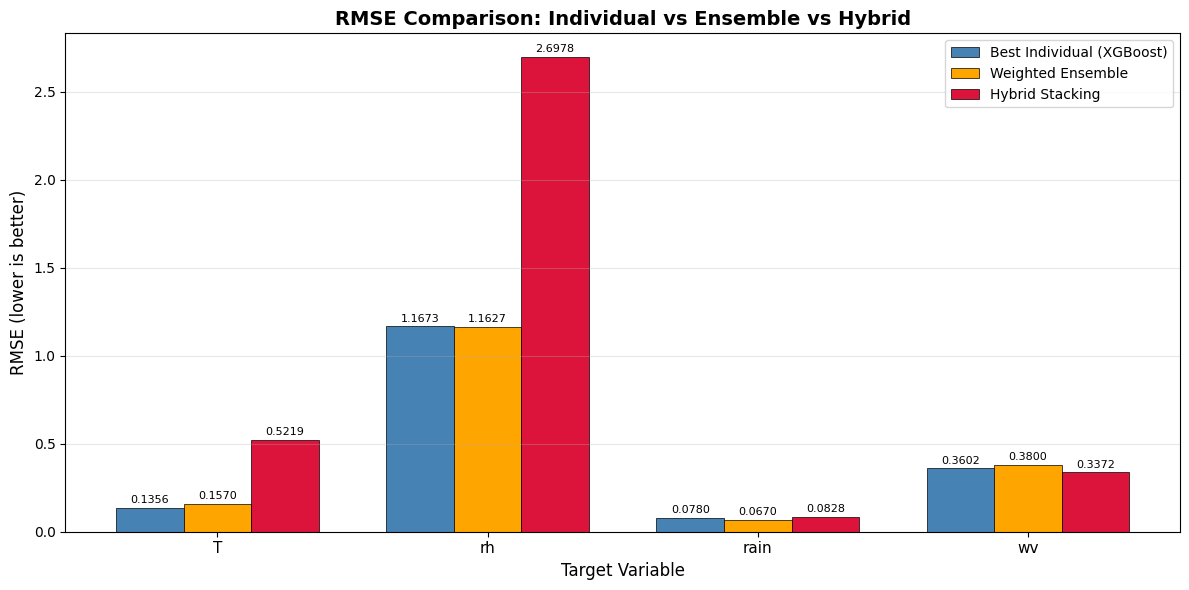

 Chart saved as hybrid_comparison.png


In [82]:
# ── VISUALIZATION: RMSE Comparison All 3 Levels ──────────
import matplotlib.pyplot as plt
import numpy as np

labels = target_cols
x      = np.arange(len(labels))
width  = 0.25

# Compute RMSE for each level
xgb_rmse      = [np.sqrt(mean_squared_error(y_test.iloc[:, i], xgb_pred[:, i]))
                  for i in range(len(target_cols))]
ensemble_rmse  = [np.sqrt(mean_squared_error(y_test.iloc[:, i], weighted_ensemble_pred[:, i]))
                  for i in range(len(target_cols))]
stacking_rmse_e  = [np.sqrt(mean_squared_error(y_test.iloc[:, i], stacking_pred_e[:, i]))
                  for i in range(len(target_cols))]

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, xgb_rmse,     width, label="Best Individual (XGBoost)",
               color="steelblue",  edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x,          ensemble_rmse, width, label="Weighted Ensemble",
               color="orange",     edgecolor="black", linewidth=0.5)
bars3 = ax.bar(x + width,  stacking_rmse_e, width, label="Hybrid Stacking",
               color="crimson",    edgecolor="black", linewidth=0.5)

ax.set_xlabel("Target Variable", fontsize=12)
ax.set_ylabel("RMSE (lower is better)", fontsize=12)
ax.set_title("RMSE Comparison: Individual vs Ensemble vs Hybrid",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=10)
ax.bar_label(bars1, fmt="%.4f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.4f", padding=2, fontsize=8)
ax.bar_label(bars3, fmt="%.4f", padding=2, fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("hybrid_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart saved as hybrid_comparison.png")

In [83]:
# ── REAL-TIME HYBRID STACKING PREDICTION ─────────────────

realtime_df       = fetch_realtime_weather()
X_realtime        = prepare_features(realtime_df, X.columns)
X_realtime_scaled = scaler.transform(X_realtime)

# Step 1 — get all 6f base model predictions
rt_base_preds_e = [
    xg_model.predict(X_realtime_scaled),
    knn_model.predict(X_realtime_scaled),
    lgbm_model.predict(X_realtime_scaled),
    cat_model.predict(X_realtime_scaled),
    ada_model.predict(X_realtime_scaled),
    rf_model.predict(X_realtime_scaled)
]

# Step 2 — stack into meta-features
meta_realtime_e = np.hstack(rt_base_preds_e)

# Step 3 — meta-learner predicts final output
hybrid_final_e = meta_learner_e.predict(meta_realtime_e)[0]

# Store with unique variable names
hybrid_T_e   = round(float(hybrid_final_e[0]), 2)
hybrid_rh_e   = round(float(hybrid_final_e[1]), 2)
hybrid_rain_e = round(float(hybrid_final_e[2]), 2)
hybrid_wv_e   = round(float(hybrid_final_e[3]), 2)

print("=" * 45)
print("    HYBRID STACKING — NEXT 10 MIN")
print("=" * 45)
print(f"  Temperature : {hybrid_T_e} °C")
print(f"  Humidity    : {hybrid_rh_e} %")
print(f"  Rain        : {hybrid_rain_e} mm")
print(f"  Wind Speed  : {hybrid_wv_e} m/s")
print("=" * 45)

C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Maithili\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


    HYBRID STACKING — NEXT 10 MIN
  Temperature : 22.19 °C
  Humidity    : 88.38 %
  Rain        : 0.01 mm
  Wind Speed  : 0.61 m/s


In [84]:
# ── WEATHER CONDITION FROM HYBRID ────────────────────────

def infer_weather_hybrid(T, rh, rain, wv):
    if rain > 0.3:
        return " Rainy"
    elif rh > 85:
        return " Cloudy"
    elif T > 25 and wv < 3:
        return " Sunny"
    elif T < 5:
        return " Cold"
    else:
        return " Normal"

condition = infer_weather_hybrid(hybrid_T_e, hybrid_rh_e,
                                  hybrid_rain_e, hybrid_wv_e)
print(f"  Condition   : {condition}")
print("=" * 45)

  Condition   :  Cloudy


In [92]:
# ============================================================
# STEP 1: SAVE ALL TRAINED MODELS WITH JOBLIB
# Add this cell at the END of your notebook (after all models are trained)
# ============================================================

import joblib
import os

# Create a folder to store models
os.makedirs("saved_models", exist_ok=True)

# Save all 8 base models
joblib.dump(xg_model,    "saved_models/xgboost_model.pkl")
joblib.dump(lgbm_model,  "saved_models/lgbm_model.pkl")
joblib.dump(cat_model,   "saved_models/catboost_model.pkl")
joblib.dump(ada_model,   "saved_models/adaboost_model.pkl")
joblib.dump(
    rf_model,
    "saved_models/randomforest_model.pkl",
    compress=('xz', 3)
)
joblib.dump(knn_model,   "saved_models/knn_model.pkl")
joblib.dump(meta_learner, "saved_models/meta_learner.pkl")
joblib.dump(svr_model,   "saved_models/svr_model.pkl")
joblib.dump(lr_model,    "saved_models/linear_model.pkl")

# Save ensemble meta-learner
joblib.dump(meta_learner, "saved_models/meta_learner.pkl")

# Save the scaler (VERY IMPORTANT — must use same scaler in the app)
joblib.dump(scaler, "saved_models/scaler.pkl")

# Save the feature column list (so app knows which columns to use)
joblib.dump(list(X.columns), "saved_models/feature_columns.pkl")

print("All models saved successfully in saved_models/ folder!")
print("Files saved:")
for f in os.listdir("saved_models"):
    print(f"  - {f}")


All models saved successfully in saved_models/ folder!
Files saved:
  - adaboost_model.pkl
  - catboost_model.pkl
  - feature_columns.pkl
  - knn_model.pkl
  - lgbm_model.pkl
  - linear_model.pkl
  - meta_learner.pkl
  - randomforest_model.pkl
  - scaler.pkl
  - svr_model.pkl
  - xgboost_model.pkl


Generating SHAP explanations...


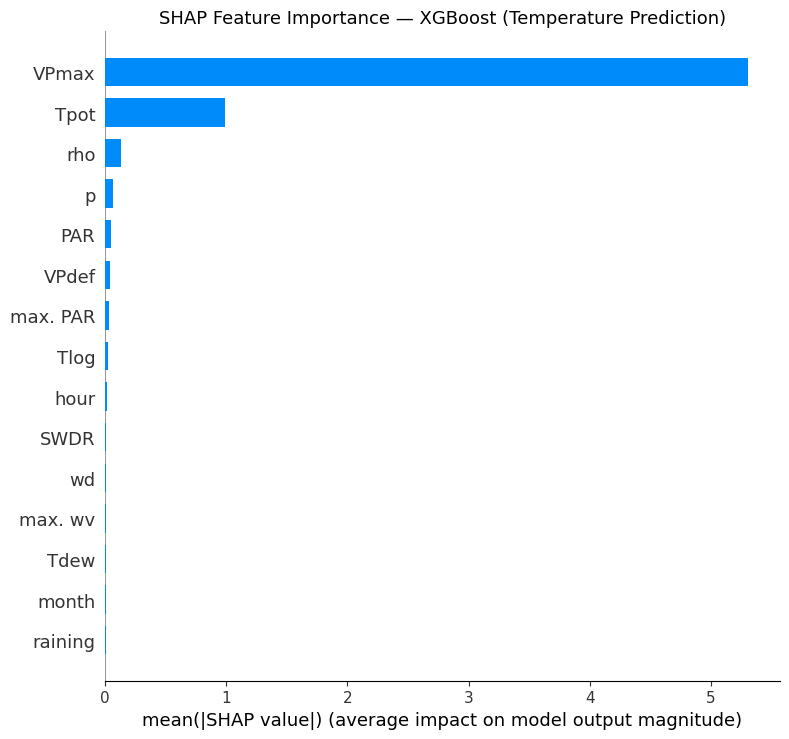

Saved: shap_bar_plot.png


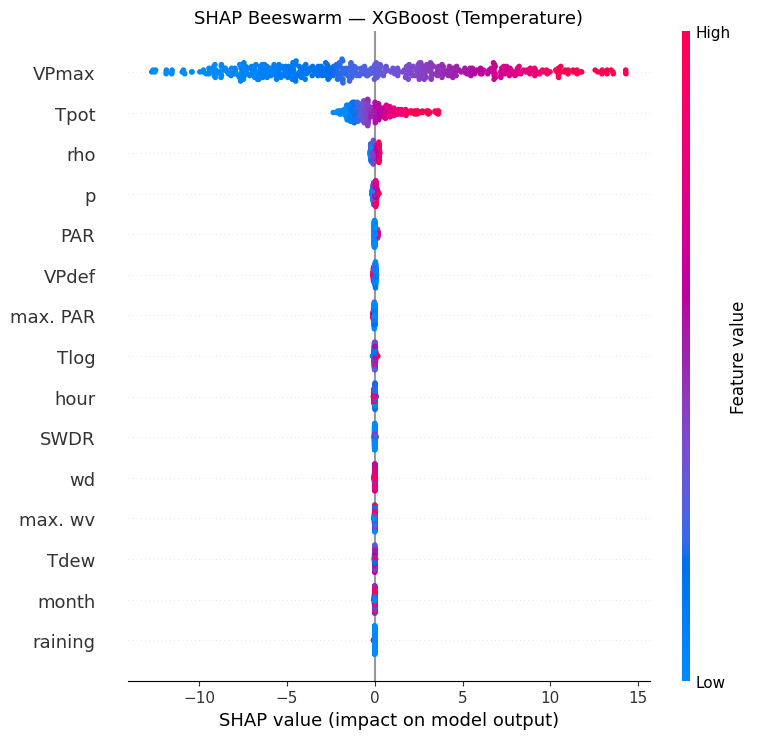

Saved: shap_beeswarm.png


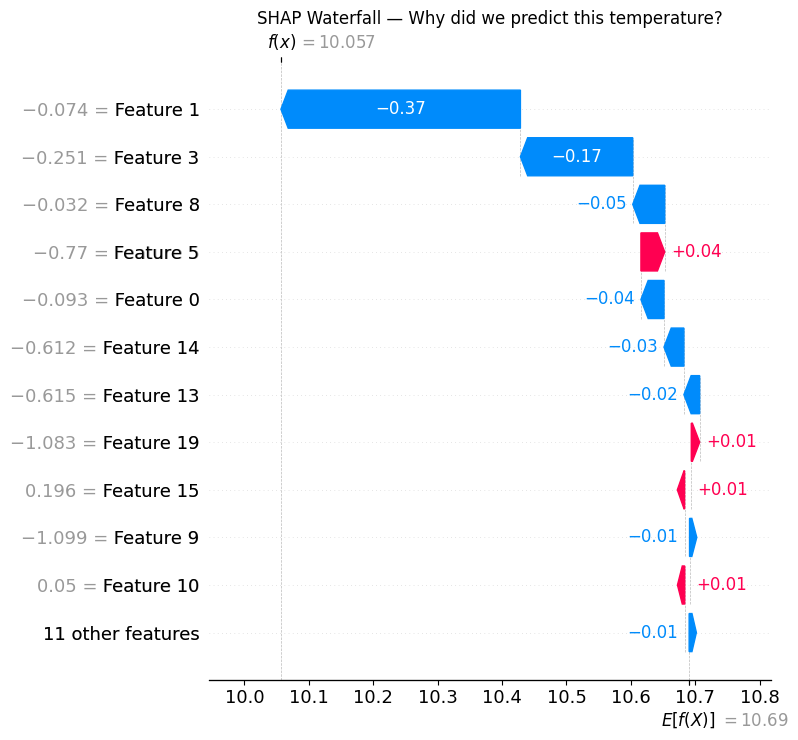

Saved: shap_waterfall.png
SHAP explainer saved!


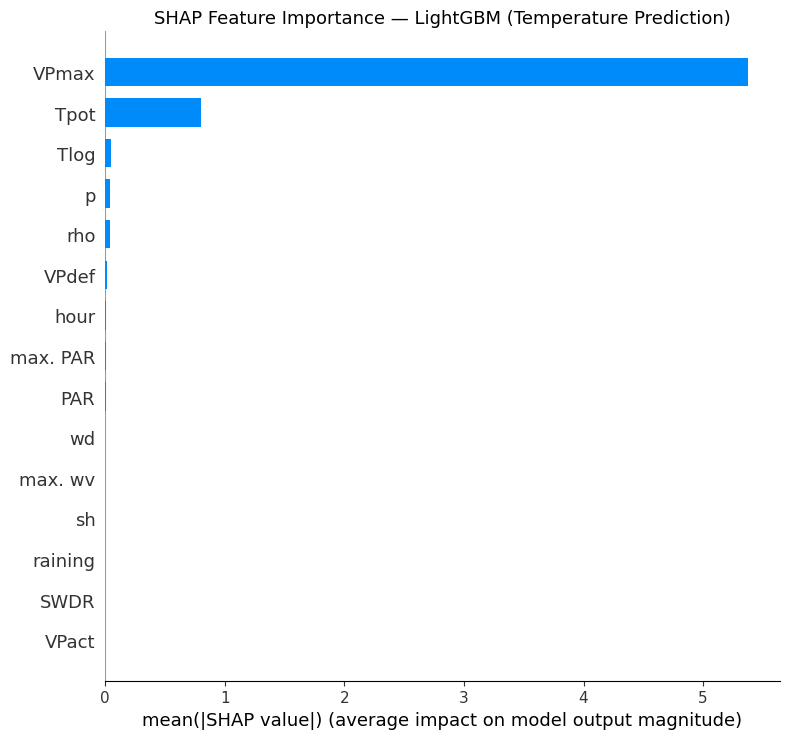

SHAP for LightGBM done!

All SHAP plots generated and saved in saved_models/ folder!


In [93]:
# ============================================================
# STEP 2: SHAP EXPLAINABILITY CODE
# Add this as a NEW CELL after the joblib saving cell
# ============================================================
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Generating SHAP explanations...")

# --- SHAP for XGBoost (best individual model) ---
# Use the first estimator of MultiOutputRegressor for temperature (index 0)
xgb_single = xg_model.estimators_[0]  # Temperature model

# Create SHAP explainer
explainer_xgb = shap.TreeExplainer(xgb_single)

# Use a sample of test data (SHAP is slow on full dataset)
X_sample = X_test_scaled[:500]
shap_values_xgb = explainer_xgb.shap_values(X_sample)

# --- Plot 1: Summary Bar Plot (Feature Importance) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_xgb,
    X_sample,
    feature_names=list(X.columns),
    plot_type="bar",
    show=False,
    max_display=15
)
plt.title("SHAP Feature Importance — XGBoost (Temperature Prediction)", fontsize=13)
plt.tight_layout()
plt.savefig("saved_models/shap_bar_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_plot.png")

# --- Plot 2: Beeswarm Summary Plot ---
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_xgb,
    X_sample,
    feature_names=list(X.columns),
    show=False,
    max_display=15
)
plt.title("SHAP Beeswarm — XGBoost (Temperature)", fontsize=13)
plt.tight_layout()
plt.savefig("saved_models/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")

# --- Plot 3: Waterfall for a SINGLE prediction (for demo in UI) ---
shap_single = explainer_xgb(X_sample[:1])
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_single[0], show=False, max_display=12)
plt.title("SHAP Waterfall — Why did we predict this temperature?", fontsize=12)
plt.tight_layout()
plt.savefig("saved_models/shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall.png")

# --- Save explainer for use in Streamlit app ---
joblib.dump(explainer_xgb, "saved_models/shap_explainer.pkl")
print("SHAP explainer saved!")

# --- SHAP for LightGBM (bonus — shows in report) ---
lgbm_single = lgbm_model.estimators_[0]
explainer_lgbm = shap.TreeExplainer(lgbm_single)
shap_values_lgbm = explainer_lgbm.shap_values(X_sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_lgbm,
    X_sample,
    feature_names=list(X.columns),
    plot_type="bar",
    show=False,
    max_display=15
)
plt.title("SHAP Feature Importance — LightGBM (Temperature Prediction)", fontsize=13)
plt.tight_layout()
plt.savefig("saved_models/shap_lgbm_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("SHAP for LightGBM done!")

print("\nAll SHAP plots generated and saved in saved_models/ folder!")


In [94]:
import os
print(os.getcwd())

C:\Users\Maithili
